# 1D Diffusion Model for Water Sorption in a Hygroscopic Hydrogel

## Physical System

We model water transport in a 1D slab of LiCl-PAM hygroscopic hydrogel of dry reference thickness $H_d$. The model is isothermal and assumes:
- water transport occurs exclusively through the polymer network,
- salt is immobile,
- evaporation and absorption occur only at the exposed outer surface.

The primary unknown is the local water concentration in the dry reference frame $c_w^{ref}(X,t)$ [mol/m³], where $X \in [0, H_d]$ is the dry reference coordinate and $t$ is time.

## Governing PDE

Water conservation combined with Fick's law gives the diffusion equation:

$$\frac{\partial c_w^{ref}}{\partial t} = \frac{\partial}{\partial X}\left(D_{eff}\frac{\partial c_w^{ref}}{\partial X}\right)$$

where $D_{eff}$ [m²/s] is the effective diffusivity of water through the polymer network.

## Boundary Conditions

**Bottom** ($X = 0$) — impermeable substrate, zero flux:

$$\frac{\partial c_w^{ref}}{\partial X}\bigg|_{X=0} = 0$$

**Top** ($X = H_d$) — surface mass transfer (Robin condition):

$$D_{eff}\frac{\partial c_w^{ref}}{\partial X}\bigg|_{X=H_d} = h_m\left[\frac{a_w P_{sat}}{RT} - \frac{RH_\infty P_{sat}}{RT}\right] = h_m\frac{P_{sat}}{RT}\left[a_w - RH_\infty\right]$$

where $h_m$ [m/s] is the external mass transfer coefficient, $P_{sat}$ [Pa] is the saturation vapor pressure of pure water, $R$ is the universal gas constant, $T$ is temperature, and $RH_\infty$ is the ambient relative humidity.

## Water Activity

The water activity $a_w$ is computed from the local composition:

$$a_w = a_w(c_w, T) $$

Is derived from the Conde relations. 

## Initial Condition

The hydrogel is assumed to be initially uniform:

$$c_w^{ref}(X, 0) = c_{w,0}^{ref}$$

# Modelling

## Import Libraries and Define Parameters

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Physical parameters
params = {
    'H_d':    {'value': 0.0023,     'unit': 'm',                  'description': 'dry reference thickness'},
    'h_m':    {'value': 0.0095,     'unit': 'm/s',                'description': 'external mass transfer coefficient'},
    'P_sat':  {'value': 3169,       'unit': 'Pa',                 'description': 'saturation pressure of water at 300K'},
    'R_gas':  {'value': 8.314472,   'unit': 'J/(mol K)',          'description': 'universal gas constant'},
    'T':      {'value': 298.15,     'unit': 'K',                  'description': 'temperature'},
    'c_s':    {'value': 11558.82,       'unit': 'mol/m3',             'description': 'salt concentration in dry reference frame'},
    'i':      {'value': 2,          'unit': '-',                  'description': 'number of ions per molecule (LiCl)'},
    'M_w':    {'value': 0.018,      'unit': 'kg/mol',             'description': 'molar mass of water'},
    'M_s':    {'value': 0.0425,     'unit': 'kg/mol',             'description': 'molar mass of salt (LiCl)'},
    'D_eff':  {'value': 1.464e-9,   'unit': 'm2/s',               'description': 'effective diffusivity (Graeber et al.)'},
}

conde_params = {
    'pi_0': {'value': 0.28,   'unit': '-', 'description': 'Conde (2004) parameter'},
    'pi_1': {'value': 4.30,   'unit': '-', 'description': 'Conde (2004) parameter'},
    'pi_2': {'value': 0.60,   'unit': '-', 'description': 'Conde (2004) parameter'},
    'pi_3': {'value': 0.21,   'unit': '-', 'description': 'Conde (2004) parameter'},
    'pi_4': {'value': 5.10,   'unit': '-', 'description': 'Conde (2004) parameter'},
    'pi_5': {'value': 0.49,   'unit': '-', 'description': 'Conde (2004) parameter'},
    'pi_6': {'value': 0.362,  'unit': '-', 'description': 'Conde (2004) parameter'},
    'pi_7': {'value': -4.75,  'unit': '-', 'description': 'Conde (2004) parameter'},
    'pi_8': {'value': -0.40,  'unit': '-', 'description': 'Conde (2004) parameter'},
    'pi_9': {'value': 0.03,   'unit': '-', 'description': 'Conde (2004) parameter'},
    'T_c':  {'value': 647.1,  'unit': 'K', 'description': 'critical temperature of pure water'},
}

sim_params = {
    'RH_des':         {'value': 0.2,    'unit': '-',   'description': 'desorption relative humidity'},
    'RH_abs':         {'value': 0.7,    'unit': '-',   'description': 'absorption relative humidity'},
    'tolerance':      {'value': 0.001,   'unit': '-',   'description': 'fractional stopping criterion for equilibrium'},
    't_switch_abs':   {'value': 2223,   'unit': 'min', 'description': 'fixed time to switch from absorption to desorption'},
    'use_fixed_time': {'value': False,   'unit': '-',   'description': 'if True, use t_switch_abs; if False, use tolerance'},
}

# Grid parameters
N     = 100                                   # number of cells
H_d   = params['H_d']['value']               # dry reference thickness [m]
dX    = H_d / N                              # cell size [m]
X_nodes = (np.arange(N) + 0.5) * dX         # node positions [m]

# Extract scalar parameters
h_m   = params['h_m']['value']
P_sat = params['P_sat']['value']
R_gas = params['R_gas']['value']
T     = params['T']['value']
c_s   = params['c_s']['value']
i_ion = params['i']['value']
M_w   = params['M_w']['value']
M_s   = params['M_s']['value']
D_eff = params['D_eff']['value']

RH_des         = sim_params['RH_des']['value']
RH_abs         = sim_params['RH_abs']['value']
tolerance      = sim_params['tolerance']['value']
use_fixed_time = sim_params['use_fixed_time']['value']
t_switch_abs   = sim_params['t_switch_abs']['value'] * 60  # convert to seconds


print(f'Grid: {N} cells, dX = {dX:.4f} m, X_nodes from {X_nodes[0]:.4f} to {X_nodes[-1]:.4f} m')

Grid: 100 cells, dX = 0.0000 m, X_nodes from 0.0000 to 0.0023 m


In [5]:
from IPython.display import display, HTML

def display_params(params):
    rows = ""
    for name, entry in params.items():
        rows += f"""
        <tr>
            <td style=\"font-style: italic; text-align: center;\">{name}</td>
            <td>{entry['value']}</td>
            <td style=\"text-align: center;\">{entry['unit']}</td>
            <td>{entry['description']}</td>
        </tr>"""

    html = f"""
    <table style=\"border-collapse: collapse; width: 100%; font-family: serif;\">
        <thead>
            <tr style=\"background-color: #f2f2f2;\">
                <th style=\"border: 1px solid black; padding: 6px; text-align: center;\">Variable</th>
                <th style=\"border: 1px solid black; padding: 6px; text-align: center;\">Value</th>
                <th style=\"border: 1px solid black; padding: 6px; text-align: center;\">Unit</th>
                <th style=\"border: 1px solid black; padding: 6px; text-align: center;\">Description</th>
            </tr>
        </thead>
        <tbody style=\"border: 1px solid black; padding: 6px;\">
            {rows}
        </tbody>
    </table>"""

    display(HTML(html))

display_params(params)
display_params(conde_params)


Variable,Value,Unit,Description
H_d,0.0023,m,dry reference thickness
h_m,0.0095,m/s,external mass transfer coefficient
P_sat,3169,Pa,saturation pressure of water at 300K
R_gas,8.314472,J/(mol K),universal gas constant
T,298.15,K,temperature
c_s,11558.82,mol/m3,salt concentration in dry reference frame
i,2,-,number of ions per molecule (LiCl)
M_w,0.018,kg/mol,molar mass of water
M_s,0.0425,kg/mol,molar mass of salt (LiCl)
D_eff,1.464e-09,m2/s,effective diffusivity (Graeber et al.)


Variable,Value,Unit,Description
pi_0,0.28,-,Conde (2004) parameter
pi_1,4.3,-,Conde (2004) parameter
pi_2,0.6,-,Conde (2004) parameter
pi_3,0.21,-,Conde (2004) parameter
pi_4,5.1,-,Conde (2004) parameter
pi_5,0.49,-,Conde (2004) parameter
pi_6,0.362,-,Conde (2004) parameter
pi_7,-4.75,-,Conde (2004) parameter
pi_8,-0.4,-,Conde (2004) parameter
pi_9,0.03,-,Conde (2004) parameter


## Import and Test Conde Relation

In [7]:
def compute_theta(T, conde_params):
    T_c = conde_params['T_c']['value']
    return T / T_c

def compute_pi_25(xi, conde_params):
    pi_6 = conde_params['pi_6']['value']
    pi_7 = conde_params['pi_7']['value']
    pi_8 = conde_params['pi_8']['value']
    pi_9 = conde_params['pi_9']['value']
    pi_25 = 1 - (1 + (xi / pi_6) ** pi_7) ** pi_8 - pi_9 * np.exp(-((xi - 0.1) ** 2) / 0.005)
    return pi_25

def compute_f(xi, theta, conde_params):
    pi_0 = conde_params['pi_0']['value']
    pi_1 = conde_params['pi_1']['value']
    pi_2 = conde_params['pi_2']['value']
    pi_3 = conde_params['pi_3']['value']
    pi_4 = conde_params['pi_4']['value']
    pi_5 = conde_params['pi_5']['value']
    A = 2 - (1 + (xi / pi_0) ** pi_1) ** pi_2  
    B = (1 + (xi / pi_3) ** pi_4) ** pi_5 - 1
    return A + B * theta

def compute_pi(xi, theta, conde_params):
    pi_25 = compute_pi_25(xi, conde_params)
    f     = compute_f(xi, theta, conde_params)
    return pi_25 * f

def compute_aw(c_w, c_s, M_w, M_s, T, conde_params):
    """
    Compute water activity a_w using Conde (2004) correlation.
    c_w : water concentration [mol/m3]
    c_s : salt concentration [mol/m3]
    xi:   salt mass fraction, i.e. the mass of salt divided by the total mass of the solution
    """
    theta = compute_theta(T, conde_params)
    xi    = (c_s * M_s) / (c_s * M_s + c_w * M_w)
    return compute_pi(xi, theta, conde_params)

# Quick sanity check
theta_test = compute_theta(T, conde_params)
print(f'theta at T={T} K: {theta_test:.4f}')


theta at T=298.15 K: 0.4607


C:\Users\maxdi\AppData\Local\Temp\ipykernel_30688\1672628370.py:10: RuntimeWarning: divide by zero encountered in scalar power
  pi_25 = 1 - (1 + (xi / pi_6) ** pi_7) ** pi_8 - pi_9 * np.exp(-((xi - 0.1) ** 2) / 0.005)


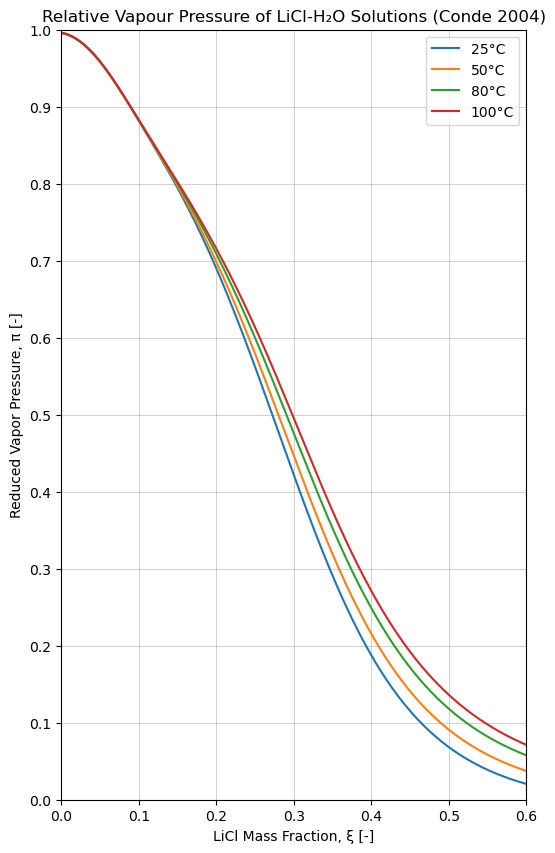

In [8]:
temperatures = {'25°C': 298.15, '50°C': 323.15, '80°C': 353.15, '100°C': 373.15}
xi_values = np.linspace(0.0, 0.6, 500)

fig, ax = plt.subplots(figsize=(6, 10))

for label, T_test in temperatures.items():
    theta = compute_theta(T_test, conde_params)
    pi_values = [compute_pi(xi, theta, conde_params) for xi in xi_values]
    ax.plot(xi_values, pi_values, label=label)

ax.set_xlabel('LiCl Mass Fraction, ξ [-]')
ax.set_ylabel('Reduced Vapor Pressure, π [-]')
ax.set_title('Relative Vapour Pressure of LiCl-H₂O Solutions (Conde 2004)')
ax.set_xlim([0.0, 0.6])
ax.set_ylim([0.0, 1.0])
ax.set_xticks(np.arange(0.0, 0.7, 0.1))
ax.set_yticks(np.arange(0.0, 1.1, 0.1))
ax.grid(True, color='grey', linewidth=0.5, linestyle='-', alpha=0.5)
ax.legend()
plt.show()

## Find Equilibrium

In [10]:
from scipy.optimize import brentq

def equilibrium_cw(RH, c_s, M_w, M_s, T, conde_params):
    """
    Find equilibrium c_w such that a_w(c_w) = RH.
    Uses Brent's method.
    """
    def residual(c_w):
        return compute_aw(c_w, c_s, M_w, M_s, T, conde_params) - RH
    return brentq(residual, 1, 1e6)



c_w_eq_low  = equilibrium_cw(RH_des, c_s, M_w, M_s, T, conde_params)
c_w_eq_high = equilibrium_cw(RH_abs, c_s, M_w, M_s, T, conde_params)

print(f'c_w_eq at RH={RH_des}: {c_w_eq_low:.1f} mol/m3')
print(f'c_w_eq at RH={RH_abs}: {c_w_eq_high:.1f} mol/m3')

# Sanity check: a_w at equilibrium should equal RH
print(f'a_w at c_w_eq_low  = {compute_aw(c_w_eq_low,  c_s, M_w, M_s, T, conde_params):.4f} (expected {RH_des})')
print(f'a_w at c_w_eq_high = {compute_aw(c_w_eq_high, c_s, M_w, M_s, T, conde_params):.4f} (expected {RH_abs})')

# Initial condition: uniform concentration at RH_des equilibrium
c_w_init = np.full(N, c_w_eq_low)
print(f'\nInitial condition: c_w_init = {c_w_eq_low:.1f} mol/m3 (uniform across all {N} cells)')

c_w_eq at RH=0.2: 42161.0 mol/m3
c_w_eq at RH=0.7: 112241.7 mol/m3
a_w at c_w_eq_low  = 0.2000 (expected 0.2)
a_w at c_w_eq_high = 0.7000 (expected 0.7)

Initial condition: c_w_init = 42161.0 mol/m3 (uniform across all 100 cells)


## Create Grid

## Numerical Implementation

### Notation

For clarity in the discretization, we define:

$$u_j^\alpha = c_w^{ref}(X_j, t^\alpha)$$

where $j = 1, \ldots, N$ is the cell index and $\alpha$ is the time step index.

### Bottom Boundary Condition ($X = 0$)

The physical BC is zero flux:

$$\frac{\partial c_w^{ref}}{\partial X}\bigg|_{X=0} = 0$$

To enforce this, we introduce a ghost node $u_0$ located at $-\Delta X/2$ from the boundary. The zero flux condition is discretized as:

$$\frac{u_1 - u_0}{\Delta X} = 0 \implies u_0 = u_1$$

Substituting into the standard implicit stencil for cell 1:

$$-r\,u_0^{\alpha+1} + (1+2r)\,u_1^{\alpha+1} - r\,u_2^{\alpha+1} = u_1^\alpha$$

replacing $u_0 = u_1$:

$$(1+r)\,u_1^{\alpha+1} - r\,u_2^{\alpha+1} = u_1^\alpha$$

where $r = D_{eff}\,\Delta t / \Delta X^2$.

### Surface Boundary Condition ($X = H_d$)

The physical BC is the surface mass transfer flux:

$$D_{eff}\frac{\partial c_w^{ref}}{\partial X}\bigg|_{X=H_d} = j_m$$

where:

$$j_m = h_m\left[\frac{a_w(u_N^\alpha, T)\, P_{sat}}{RT} - \frac{RH_\infty\, P_{sat}}{RT}\right] = h_m\frac{P_{sat}}{RT}\left[a_w(u_N^\alpha, T) - RH_\infty\right]$$

To enforce this, we introduce a ghost node $u_{N+1}$ located at $\Delta X/2$ beyond the right boundary. The flux at the right face is discretized as:

$$D_{eff}\frac{u_{N+1}^{\alpha+1} - u_N^{\alpha+1}}{\Delta X} = j_m(u_N^\alpha, T) \implies u_{N+1}^{\alpha+1} = u_N^{\alpha+1} + \frac{j_m(u_N^\alpha, T)\, \Delta X}{D_{eff}}$$

Note that $j_m$ is evaluated using $u_N^\alpha$ (the surface concentration at the previous time step) rather than $u_N^{\alpha+1}$. This is an explicit treatment of the nonlinear BC, which simplifies the implementation by keeping the matrix $A$ linear. It introduces a splitting error of $\mathcal{O}(\Delta t)$ at the boundary and could be a source of inaccuracy if the surface concentration changes rapidly between time steps — for instance in the convection-limited regime.

Substituting into the standard implicit stencil for cell $N$:

$$-r\,u_{N-1}^{\alpha+1} + (1+2r)\,u_N^{\alpha+1} - r\,u_{N+1}^{\alpha+1} = u_N^\alpha$$



Substituting $u_{N+1}^{\alpha+1} = u_N^{\alpha+1} + \frac{j_m(u_N^\alpha, T)\,\Delta X}{D_{eff}}$ into the stencil:

$$-r\,u_{N-1}^{\alpha+1} + (1+2r)\,u_N^{\alpha+1} - r\left(u_N^{\alpha+1} + \frac{j_m(u_N^\alpha, T)\,\Delta X}{D_{eff}}\right) = u_N^\alpha$$

Expanding and collecting $u_N^{\alpha+1}$ terms:

$$-r\,u_{N-1}^{\alpha+1} + (1+r)\,u_N^{\alpha+1} = u_N^\alpha + r\frac{j_m(u_N^\alpha, T)\,\Delta X}{D_{eff}}$$

So the last row of $A$ and last entry of $\mathbf{b}$ are:

$$a_{N,N-1} = -r, \quad a_{NN} = (1+r), \quad b_N = u_N^\alpha + r\frac{j_m(u_N^\alpha, T)\,\Delta X}{D_{eff}}$$


### Complete Linear System

The full discretized system $A\,\mathbf{c}^{\alpha+1} = \mathbf{b}$ is:

$$\begin{pmatrix} (1+r) & -r & 0 & \cdots & 0 \\ -r & (1+2r) & -r & \cdots & 0 \\ 0 & -r & (1+2r) & \cdots & 0 \\ \vdots & & \ddots & \ddots & \vdots \\ 0 & \cdots & 0 & -r & (1+r) \end{pmatrix} \begin{pmatrix} u_1^{\alpha+1} \\ u_2^{\alpha+1} \\ u_3^{\alpha+1} \\ \vdots \\ u_N^{\alpha+1} \end{pmatrix} = \begin{pmatrix} u_1^{\alpha} \\ u_2^{\alpha} \\ u_3^{\alpha} \\ \vdots \\ u_N^\alpha + r\dfrac{j_m(u_N^\alpha, T)\,\Delta X}{D_{eff}} \end{pmatrix}$$

where $r = D_{eff}\,\Delta t / \Delta X^2$, and $j_m$ is evaluated explicitly at time $\alpha$:

$$j_m(u_N^\alpha, T) = h_m\frac{P_{sat}}{RT}\left[a_w(u_N^\alpha, T) - RH_\infty\right]$$

At each time step $\alpha$:
1. Compute $j_m$ from the current surface concentration $u_N^\alpha$
2. Assemble $\mathbf{b}$ using $u^\alpha$ and $j_m$
3. Solve $A\,\mathbf{c}^{\alpha+1} = \mathbf{b}$ for the new concentration vector
4. Update $u^\alpha \leftarrow u^{\alpha+1}$ and proceed to the next time step

In [15]:
print('--- Simulation Parameters ---')
print(f'  N             = {N}')
print(f'  H_d           = {H_d} m')
print(f'  dX            = {dX:.6f} m')
print(f'  T             = {T} K')
print(f'  P_sat         = {P_sat} Pa')
print(f'  R_gas         = {R_gas} J/(mol K)')
print(f'  c_s           = {c_s} mol/m³')
print(f'  M_w           = {M_w} kg/mol')
print(f'  M_s           = {M_s} kg/mol')
print(f'  h_m           = {h_m} m/s')
print(f'  D_eff         = {D_eff:.2e} m²/s')
print(f'  RH_low        = {RH_des}')
print(f'  RH_high       = {RH_abs}')
print(f'  c_w_eq_low    = {c_w_eq_low:.1f} mol/m³')
print(f'  c_w_eq_high   = {c_w_eq_high:.1f} mol/m³')

--- Simulation Parameters ---
  N             = 100
  H_d           = 0.0023 m
  dX            = 0.000023 m
  T             = 298.15 K
  P_sat         = 3169 Pa
  R_gas         = 8.314472 J/(mol K)
  c_s           = 11558.82 mol/m³
  M_w           = 0.018 kg/mol
  M_s           = 0.0425 kg/mol
  h_m           = 0.0095 m/s
  D_eff         = 1.46e-09 m²/s
  RH_low        = 0.2
  RH_high       = 0.7
  c_w_eq_low    = 42161.0 mol/m³
  c_w_eq_high   = 112241.7 mol/m³


In [16]:
import numpy as np

# --- Step 1: Large diffusivity for validation ---
D_eff_large = D_eff
# --- Step 2: Time step and diffusion number ---
dt = 1  # s
r  = D_eff_large * dt / dX**2
print(f'r = {r:.4e}')

# --- Step 3: Assemble tridiagonal matrix A (constant) ---
A = np.zeros((N, N))

# First row: zero-flux BC (bottom)
A[0, 0] =  1 + r
A[0, 1] = -r

# Interior rows
for j in range(1, N-1):
    A[j, j-1] = -r
    A[j, j]   =  1 + 2*r
    A[j, j+1] = -r

# Last row: Robin BC (surface)
A[N-1, N-2] = -r
A[N-1, N-1] =  1 + r

# --- Step 4: Initialize concentration ---
c_w = np.ones(N) * c_w_eq_low

print('Matrix A assembled successfully')
print(f'A shape: {A.shape}')
print(f'Initial concentration: {c_w[0]:.1f} mol/m³ (uniform across all {N} cells)')

r = 2.7675e+00
Matrix A assembled successfully
A shape: (100, 100)
Initial concentration: 42161.0 mol/m³ (uniform across all 100 cells)


In [17]:
from scipy.linalg import solve

# --- Absorption phase ---
RH_now      = RH_abs
tolerance   = 0.01

c_w_abs     = c_w.copy()  # starting from initial condition (numpy array, shape (N,))
t_now       = 0.0

t_abs       = [0.0]
cw_mean_abs = [np.mean(c_w_abs)]
C_abs       = [c_w_abs.copy()]

max_iterations = 1000000
iterations = 1

In [18]:
while True:
    
    # Step 1: compute j_m from surface node (explicit)
    aw_surface = compute_aw(float(c_w_abs[N-1]), c_s, M_w, M_s, T, conde_params)
    j_m        = h_m * (P_sat / (R_gas * T)) * (aw_surface - RH_now)

    # Step 2: assemble b
    b        = c_w_abs.copy()
    b[-1]   -= r * j_m * dX / D_eff_large

    # Step 3: solve
    c_w_new  = solve(A, b)

    # Step 4: update
    c_w_abs  = c_w_new

    # Step 5: store
    t_now   += dt
    t_abs.append(t_now)
    cw_mean_abs.append(np.mean(c_w_abs))
    C_abs.append(c_w_abs.copy())

    # Step 6: stopping criterion
    if iterations == max_iterations:
        print(f'Loop terminated: reached max iterations ({max_iterations})')
        break
    
    if use_fixed_time:
        if t_now >= t_switch_abs:
            print(f'Loop terminated: reached fixed switch time {t_switch_abs/60:.0f} min after {iterations} iterations')
            break
    else:
        if np.mean(c_w_abs) >= c_w_eq_low + (1 - tolerance) * (c_w_eq_high - c_w_eq_low):
            print(f'Loop terminated: reached equilibrium within tolerance {tolerance*100:.1f}% after {iterations} iterations')
            break
    
    iterations = iterations + 1
    

# Convert to numpy arrays
t_abs       = np.array(t_abs)
cw_mean_abs = np.array(cw_mean_abs)
C_abs       = np.array(C_abs)  # shape: (N_steps, N)

print(f'Absorption complete: {len(t_abs)} steps, t_final = {t_abs[-1]:.1f} s')
print(f'Final mean c_w = {cw_mean_abs[-1]:.1f} mol/m³  (target: {c_w_eq_high * (1 - tolerance):.1f} mol/m³)')
print(f'C_abs shape: {C_abs.shape}')
print(f'c_w mean (initial)    = {np.mean(c_w_abs):.1f} mol/m³')

Loop terminated: reached equilibrium within tolerance 1.0% after 239419 iterations
Absorption complete: 239420 steps, t_final = 239419.0 s
Final mean c_w = 111540.9 mol/m³  (target: 111119.3 mol/m³)
C_abs shape: (239420, 100)
c_w mean (initial)    = 111540.9 mol/m³


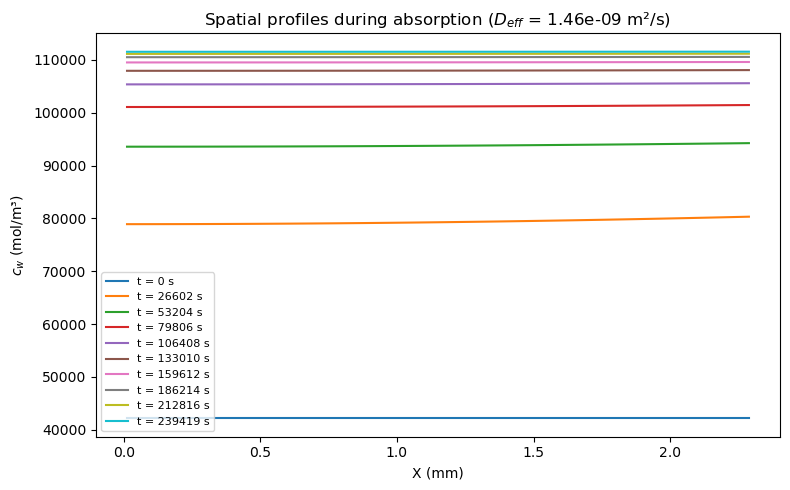

c_w_eq at RH=0.2: 42161.0 mol/m^3
c_w_eq at RH=0.7: 112241.7 mol/m^3


In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

n_snapshots = 10
indices = np.linspace(0, len(t_abs)-1, n_snapshots, dtype=int)

for idx in indices:
    ax.plot(X_nodes * 1000, C_abs[idx], label=f't = {t_abs[idx]:.0f} s')

ax.set_xlabel('X (mm)')
ax.set_ylabel('$c_w$ (mol/m³)')
#ax.set_title('Spatial profiles during absorption ($D_{eff} \\to \\infty$)')
ax.set_title(f'Spatial profiles during absorption ($D_{{eff}}$ = {D_eff_large:.2e} m²/s)')

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'c_w_eq at RH=0.2: {c_w_eq_low:.1f} mol/m^3')
print(f'c_w_eq at RH=0.7: {c_w_eq_high:.1f} mol/m^3')

In [20]:
# Modified Biot number (Equation 9, Díaz-Marín et al. 2024)
Bi = (H_d * h_m / D_eff) * (i_ion * c_s * P_sat / (R_gas * T)) / (c_w_eq_high + i_ion * c_s)**2

print(f'--- Modified Biot Number ---')
print(f'  H_d       = {H_d*1000:.2f} mm')
print(f'  h_m       = {h_m} m/s')
print(f'  D_eff     = {D_eff:.2e} m²/s')
print(f'  i*c_s     = {i_ion*c_s:.1f} mol/m³')
print(f'  c_w,inf   = {c_w_eq_high:.1f} mol/m³')
print(f'  Bi        = {Bi:.4f}')

if Bi < 0.01:
    print('  Regime: convection-limited (0D model valid, error < 2%)')
elif Bi < 0.1:
    print('  Regime: transitional (0D model acceptable, error < 20%)')
else:
    print('  Regime: diffusion-limited (1D model required)')

--- Modified Biot Number ---
  H_d       = 2.30 mm
  h_m       = 0.0095 m/s
  D_eff     = 1.46e-09 m²/s
  i*c_s     = 23117.6 mol/m³
  c_w,inf   = 112241.7 mol/m³
  Bi        = 0.0241
  Regime: transitional (0D model acceptable, error < 20%)


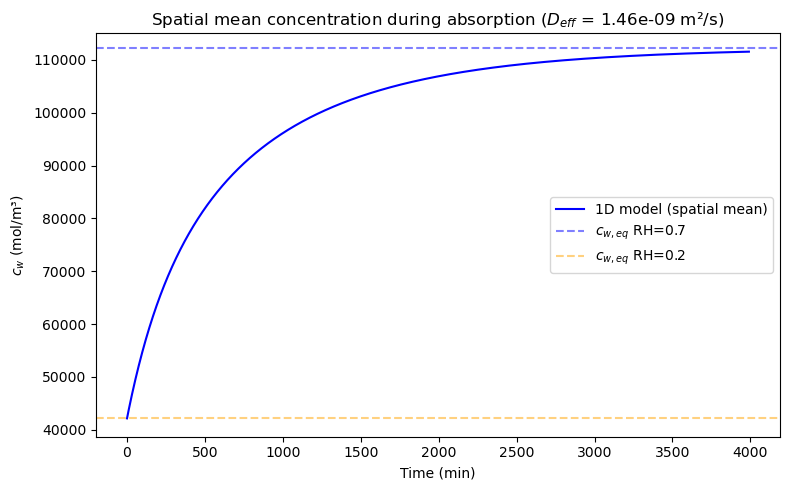

Absorption complete: 239420 steps, t_final = 239419.0 s / 3990.3 min


In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_abs / 60, cw_mean_abs, color='blue', label='1D model (spatial mean)')
ax.axhline(y=c_w_eq_high, color='blue', linestyle='--', alpha=0.5, label='$c_{w,eq}$ RH=0.7')
ax.axhline(y=c_w_eq_low, color='orange', linestyle='--', alpha=0.5, label='$c_{w,eq}$ RH=0.2')

ax.set_xlabel('Time (min)')
ax.set_ylabel('$c_w$ (mol/m³)')
ax.set_title(f'Spatial mean concentration during absorption ($D_{{eff}}$ = {D_eff:.2e} m²/s)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Absorption complete: {len(t_abs)} steps, t_final = {t_abs[-1]:.1f} s / {t_abs[-1]/60:.1f} min')


In [22]:
# --- Desorption phase ---
RH_now      = RH_des

c_w_des     = c_w_abs.copy()  # start from final absorption state
t_now       = 0.0

t_des       = [0.0]
cw_mean_des = [np.mean(c_w_des)]
C_des       = [c_w_des.copy()]

iterations  = 1

while True:

    # Step 1: compute j_m from surface node (explicit)
    aw_surface = compute_aw(float(c_w_des[N-1]), c_s, M_w, M_s, T, conde_params)
    j_m        = h_m * (P_sat / (R_gas * T)) * (aw_surface - RH_now)

    # Step 2: assemble b
    b        = c_w_des.copy()
    b[-1]   -= r * j_m * dX / D_eff_large

    # Step 3: solve
    c_w_new  = solve(A, b)

    # Step 4: update
    c_w_des  = c_w_new

    # Step 5: store
    t_now   += dt
    t_des.append(t_now)
    cw_mean_des.append(np.mean(c_w_des))
    C_des.append(c_w_des.copy())

    # Step 6: stopping criterion
    if iterations == max_iterations:
        print(f'Loop terminated: reached max iterations ({max_iterations})')
        break

    if np.mean(c_w_des) <= c_w_eq_high - (1 - tolerance) * (c_w_eq_high - c_w_eq_low):
        print(f'Loop terminated: reached equilibrium within tolerance {tolerance*100:.1f}% after {iterations} iterations')
        break

    iterations += 1

# Convert to numpy arrays
t_des       = np.array(t_des)
cw_mean_des = np.array(cw_mean_des)
C_des       = np.array(C_des)  # shape: (N_steps, N)

print(f'Desorption complete: {len(t_des)} steps, t_final = {t_des[-1]:.1f} s / {t_des[-1]/60:.1f} min')
print(f'Final mean c_w = {cw_mean_des[-1]:.1f} mol/m³  (target: {c_w_eq_high - (1 - tolerance) * (c_w_eq_high - c_w_eq_low):.1f} mol/m³)')

Loop terminated: reached equilibrium within tolerance 1.0% after 91502 iterations
Desorption complete: 91503 steps, t_final = 91502.0 s / 1525.0 min
Final mean c_w = 42861.8 mol/m³  (target: 42861.8 mol/m³)


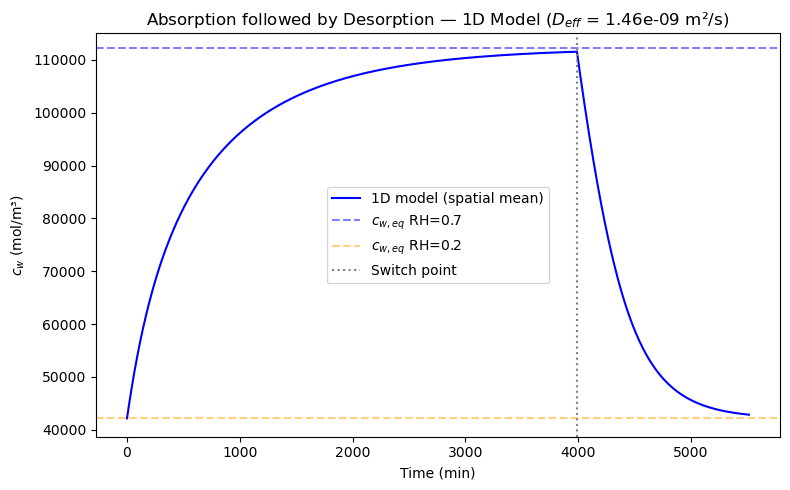

Absorption time: 239419.0 s / 3990.3 min
Desorption time: 91502.0 s / 1525.0 min


In [23]:
t_des_offset = t_des + t_abs[-1]
t_combined   = np.concatenate([t_abs, t_des_offset])
cw_combined  = np.concatenate([cw_mean_abs, cw_mean_des])

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_combined / 60, cw_combined, color='blue', label='1D model (spatial mean)')
ax.axhline(y=c_w_eq_high, color='blue',   linestyle='--', alpha=0.5, label='$c_{w,eq}$ RH=0.7')
ax.axhline(y=c_w_eq_low,  color='orange', linestyle='--', alpha=0.5, label='$c_{w,eq}$ RH=0.2')
ax.axvline(x=t_abs[-1] / 60, color='gray', linestyle=':', label='Switch point')

ax.set_xlabel('Time (min)')
ax.set_ylabel('$c_w$ (mol/m³)')
ax.set_title(f'Absorption followed by Desorption — 1D Model ($D_{{eff}}$ = {D_eff:.2e} m²/s)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Absorption time: {t_abs[-1]:.1f} s / {t_abs[-1]/60:.1f} min')
print(f'Desorption time: {t_des[-1]:.1f} s / {t_des[-1]/60:.1f} min')

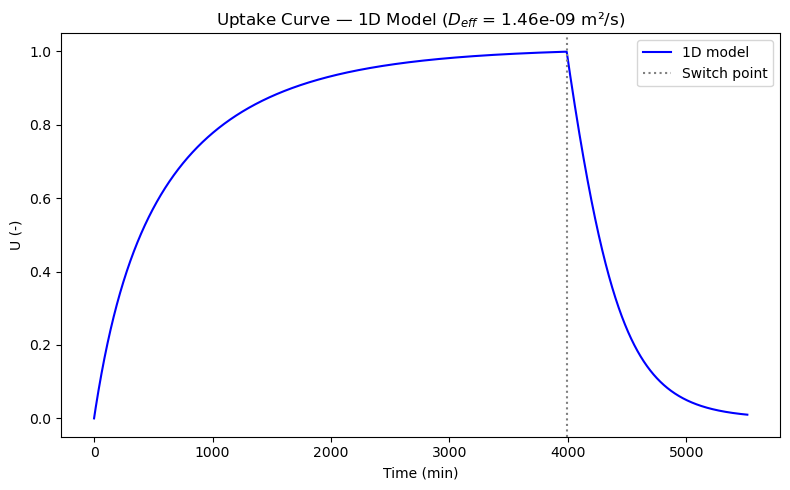

In [24]:
u_abs = (cw_mean_abs - c_w_eq_low) * M_w / (c_w_eq_low * M_w + c_s * M_s)
u_des = (cw_mean_des - c_w_eq_low) * M_w / (c_w_eq_low * M_w + c_s * M_s)

u_combined = np.concatenate([u_abs, u_des])

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_combined / 60, u_combined, color='blue', label='1D model')
ax.axvline(x=t_abs[-1] / 60, color='gray', linestyle=':', label='Switch point')

ax.set_xlabel('Time (min)')
ax.set_ylabel('U (-)')
ax.set_title(f'Uptake Curve — 1D Model ($D_{{eff}}$ = {D_eff:.2e} m²/s)')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
from scipy.optimize import curve_fit

U_inf = u_abs[-1]

# Fitting functions
def f_abs_fit(t, tau):
    return U_inf * (1 - np.exp(-t / tau))

def f_des_fit(t, tau):
    return U_inf * np.exp(-t / tau)

# Fit absorption
popt_abs, _ = curve_fit(f_abs_fit, t_abs, u_abs, p0=[t_abs[-1] / 2])
tau_abs = popt_abs[0]

# Fit desorption
popt_des, _ = curve_fit(f_des_fit, t_des, u_des, p0=[t_des[-1] / 2])
tau_des = popt_des[0]

print(f'tau_abs = {tau_abs:.1f} s / {tau_abs/60:.1f} min')
print(f'tau_des = {tau_des:.1f} s / {tau_des/60:.1f} min')
print(f'tau_abs + tau_des = {(tau_abs + tau_des)/60:.1f} min')

tau_abs = 38469.1 s / 641.2 min
tau_des = 21966.2 s / 366.1 min
tau_abs + tau_des = 1007.3 min


In [26]:
import json
import os

# Downsample
n = 100
run_data = {
    'metadata': {
        'RH_des':     RH_des,
        'RH_abs':     RH_abs,
        'H0':         H_d,
        'g':          h_m,
        'N':          N,
        'downsample': n,
    },
    't_combined':   t_combined[::n].tolist(),
    'u_combined':   u_combined[::n].tolist(),
    'c_w_combined': cw_combined[::n].tolist(),
    'u_abs':        u_abs[::n].tolist(),
    'u_des':        u_des[::n].tolist(),
    'tau_abs':      float(tau_abs / 60),
    'tau_des':      float(tau_des / 60),
    'Bi':           float(Bi),
}

if use_fixed_time:
    stop_label = f'tfix{int(t_switch_abs/60)}'
else:
    stop_label = f'tol{int(tolerance*1000)}'

filename = f'results/run_1D_RH{int(RH_des*100)}-{int(RH_abs*100)}-{int(RH_des*100)}_H{int(H_d*1000)}mm_g{int(h_m*10000)}_N{N}_{stop_label}_ds{n}.json'

os.makedirs('results', exist_ok=True)
with open(filename, 'w') as fout:
    json.dump(run_data, fout)

print(f'Saved to {filename}')

Saved to results/run_1D_RH20-70-20_H2mm_g95_N100_tol10_ds100.json
